
---
REPOSITORY STRUCTURE -- The Big Picture
   The repo splits into two halves: STUFF THE ORGANISERS PROVIDE (evaluation
   infrastructre) and STUFF YOU IMPLEMENT (your policy).


  aic/
  ├── docs/                    # 12+ documentation guides
  │
  ├── ORGANIZER SIDE (evaluation):
  │   ├── aic_engine/          # Trail orchestration & validation       [DOCUMENTED]
  │   ├── aic_bringup/         # Launch files for simulation            [DOCUMENTED]
  │   ├── aic_controller/      # Low-level robot control (ros2_control)
  │   ├── aic_adapter/         # Sensor fusion & synchronisation
  │   ├── aic_gazebo/          # Gazebo physics plugins
  │   ├── aic_scoring/         # Automated scoring system
  │   ├── aic_description/     # URDF/SDF & environment models
  │   └── aic_assets/          # 3D models (meshes, textures)
  │
  ├── YOUR SIDE (participant):
  │   ├── aic_model/           # Policy framework template (implement this!)
  │   ├── aic_example_policies/# Reference implementations to learn from [DOCUMENTATION]
  │   └── aic_interfaces/      # ROS 2 message/service/action definitions
  │
  ├── aic_utils/               # Utilities (teleoperation, MuJuCo, LeRobot)
  ├── docker/                  # Container definitions for submission
  ├── pixi.toml                # Dependency manager config
  └── aic.repos                # External dependency manifest


---
THE CORE PACKAGES IN DETAIL
   
1. `aic_model/` - YOUR POLICY FRAMEWORK
   This is the template you build on. It has two key files:

   `aic_model.py` (275 lines) - A ROS 2 lifecycle node that handles all the
   boilerplate: loading your policy dynamically, managing lifecycle states,
   implementing the `/insert_cable` action server, and publishing motion
   commands.

   `policy.py` (146 lines) - The abstract base class you subclass. Your job is
   to implement one method:

```Python
class MyPolicy(Policy):
    def insert_cable(self, task, get_observation, move_robot, send_feedback):
        observation = get_observation()      # Sensor data @ 20 Hz
        # Process observation, compute target pose
        move_robot(motion_update=...)        # Send command to controller
        send_feedback("inserting cable...")
        return True                          # Task success
```
   The helpers you get: `set_pose_target()`, `time_now()`, `sleep_for()`, 
   `get_logger()`.



2. `aic_interfaces/` - COMMUNICATION PROTOCOLS
   These define hwo everything talks to each other via ROS 2:

   TASK INTERFACE:
   * `InsertCable.action` - The main action: Goal (Task) -> Result (success +
     message) + Feedback (string)
   * `Task.msg` - Contains: `cable_name`, `plug_name`, `plug_type`, `port_name`,
     `port_type`, `target_module_name`, `time_limit`

   CONTROL INTERFACE: 
   - `MotionUpdate.msg` - Cartesian impedance control (pose, velocity, stiffness
     matrix, damping matrix, feedforward wrench)
   - `JointMotionUpdate.msg` - Joint-space control (positions, velocities,
     accelerations + impedance params)
   - `ChangeTableMode.srv` - Switch between Cartesian and Joint control

   OBSERVATION INTERFACE:
   - `Observation.msg` - Composite at 20 Hz: 3 camera images, camera_info, joint
     states, wrist wrench (F/T), controller state (TCP pose/velocity, tracking
     error)



3. `aic_engine/` - TRAIL ORCHESTRATOR
   Automates the evaluation pipeline. For each trail it:
   1. Validates your model is a proper ROS 2 Lifecycle node
   2. Spawns the task board from YAML config
   3. Sends cable insertion tasks via `/insert_cable`
   4. Monitors execution
   5. Collects scoring data

   Configuration is YAML-driven:
```yaml
trials:
  trial_1:
    scene:
      task_board: {pose, nic_rails[], sc_rails[], mount_rails[]}
      cable: {cable_type, pose}
```
   
4. `aic_controller/` - ROBOT CONTROL
   Based on `ros2_control`. Two modes:
   - CARTESIAN IMPEDANCE CONTROL - Track TCP pose targets with tunable 
     stiffness/damping
   - JOINT-SPACE CONTROL - Direct joint position/velocity targets

   Features admittance control for interaction forces, F/T sensor integration,
   and real-time trajectory generation. 


5. `aic_adapter/` - SENSOR FUSION
   C++ node that subscribes to all async sensor streams (3 cameras, joint states
   , F/T sensor, controller state), time-aligns them in deque buffers, and
   publishes a composite `Obervsation` message at 20 Hz.


6. `aic_gazebo/` - PHYSICS PLUGINS
   Five Gazebo plugins:
   - ScoringPlugin - Publishes scoring data via Protobuf
   - Cableplugin - Cable attachment/detachment physics
   - OffLimitContactsPlugin - Collision detection with restricted areas
   - ResetJointsPlugin - Joint state reset service
   - WorldSdfGeneratorPlugin - Saves SDF snapshots to `/tmp/aic.sdf`


7. `aic_scoring/` - HOW YOU GET SCORED

Three-tier system, 100 points max per trail:

TIER 1 - MODEL VALIDITY (1 point)
   - Binary: does your model load and respond to actions?

TIER 2 - PERFORMANCE METRICS (up to 30 points, penalties possible)
   - TRAJECTORY SMOOTHNESS (0-6 pts): Lower jerk = more points. Jerk=0 -> 6 pts,
     Jerk >= 50 m/s^3 -> 0 pts#
   - TASK DURATION (0-12 pts): 5s or less -> 12 pts, 60s+ -> 0 pts
   - TRAJECTORY EFFICIENCY (0-6 pts): Shorter path = more points
   - FORCE PENALTY (0 to -12 pts): Penalty if force > 20N for > 1 seconds.
   - Off-Limit Contact (-24 pts): Touch the walls/enclosure and you're punished
     hard

TIER 3 - TASK SUCCESS (up to 75 points)     
   - Full correct insertion: 75 pts
   - Wrong port: -12 pts
   - Partial insertion (plug inside port bounding box): 38-50 pts proportional
     to depth
   - Proximity (plug near port): 0-25 pts distance-based



8. `aic_description/` - The Simulation World

ROBOT URDF (`ur_gz.urdf.xacro`): Full UR5e with cameras, gripper, F/T sensor,
all configurable.

TASK BOARD (`task_board.urdf.xacro`): Modular and randomisable:
   - Zone 1: NIC Cards (up to 5) with SFP ports
   - Zone 2: SC Ports (up to 5 on 2 rails)
   - Zones 3-4: Pick locations (mount rails for LC, SFP, SC)
   - All positions randomisable within defined limits

CABLE MODELS (`cable.sdf.xacro`): SFP-SC cables with physics, self-collision, 
and attachment plugins. 

WORLD (`aic.sdf`): Bullet-Featherstone physics engine, 2ms timestep, real-time
factor 1.0, enclosure with lighting 



---
THE EXAMPLE POLICIES - Learn From These

   `WaveArm.py` (85 lines) - Minimal Example
   - Oscillates the arm side-to-side for 10 seconds. Shows the basic API:
     `get_observation()`, `set_pose_target()`, `sleep_for()`

   `CheatCode.py` (260 lines) - Ground Truth Policy
   - Uses ground truth TF frames (only works with `ground_truth := true`). 
     Precisely aligns plug to port using quaternion math, smooth interpolation
     (100 steps), and PI control for xy alignment. STUDY THIS ONE CLOSELY --
     it shows the ideal motion strategy.

   `RunACT.py` (500+ lines) - Neural Network Policy
   - The deep learning reference. Downloads an ACT (Action Chunking with 
     Transformers) model from HuggingFace, processing camera images, normalises
     robot state, runs inference, and sends joint velocity commands. Uses
     LeRobot, PyTorch, OpenCV. 

   `GentleGiant.py` - Smooth motion
   - Low stiffness, high damping, slow controlled motion. Optimises for the
     jerk score.

   `SpeedDemon.py` - Fast/Jerky Motion
   - High stiffness, low damping, aggressive movement. Shows what NOT to do for
     smoothness scoring.

   `WallToucher.py` - Collision Testing    
   - Deliberately extends arm toward enclosure wall. Tests the off-limit contact
     penalty system.



---
DOCKER & SUBMISSION
   Your submission is a Docker container:

```Python
FROM ros:kilted-ros-score
# Build with pixi, install dependencies
# Entry: pixi run ros2 run aic_model aic_model --ros-args -p policy:=your_policy.module.Class
```
   Uses ZENOH as the ROS middleware for cloud evaluation. Access control 
   prevents cheating.


---
CHALLENGE RULES - What You Can't Do

   - No teleporting components or bypassing physics
   - No unauthorised ROS parameter modification
   - No accessing `/gazebo`, `/gz_server`, `/scoring` namespaces
   - No hardcoded sensor data specific to evaluation secnarios
   - Ground truth data ONLY for training, not in evaluation
   - Containers are audited   



---

   







---

Axctio

-- Quaternions are a 4D number systems extending complex numbers, ... They are
   primarily used to represent 3D rotations and orientations in computer 
   graphics, robotics, and aerospace, offering efficient computation that avoids
   numerical instability and gimbal lock issues associated with Euler angles. 





   ROS-2 is a decentralised, modular middleware framework for robotics, 
   utilising DDS (Data Distribution Service) for robust, secure and real-time
   communication between ndoes. Key concepts include nodes (functional units),
   topics (publish-subscribe messaging), services (request-reply), actions
   (long-running tasks), and parameters (configuration), all facilitating
   scalable robot development.

CORE ROS-2 CONCEPTS EXPLAINED: 
   - NODES: Independent, specialised programs that perform specific tasks (e.g.,
     one node for camera data, another for motor control)
   - TOPICS: The primary method for data exchange. Nodes publish data to a topic
     (e.g., `/scan`) and subscribe to topics to receive data, allowing 
     many-to-many communication.
   - MESSAGES: The specific data types (structure) sent over topics (e.g., 
     `sensor_msgs/msg/LaserScan`).
   - SERVICES: A synchronous request/reply mechanism used when a node needs a 
     quick, immediate action from another (e.g., turning on a service).
   - ACTIONS: Asynchronous, pre-emptable, and long-running goal-based 
     communication. Ideal for complex tasks like navigating to a location, 
     providing feedback during execution. 
   - PARAMETERS: Configurable parameters (e.g., maximum speed) that can be
     changed dynamicaly at runtime.
   - ROS GRAPH: The network of all nodes and their connections to each other.
   - QUALITY OF SERVICE (QoS): Policies (reliability, durability) that allow
     developers to tune communication settings for specific needs, such as
     ensuring critical data is never lsot.
   - DISCOVERY: The automatic process by which nodes find and connect to
     other nodes in the network without a central master.     



   ... to understand your SO-101 robotic arm, you have to think of it as a 
   KINEMATIC CHAIN: a series of rigid bodies (links) connected by joints that
   provide constrained motion.

   In the real world, these aren't just abstract math; they are the literal
   "bones" and "muscles" of your robot.


---
1. SERIAL KINEMATIC CHAIN (Open Chain)   
   This is what your SO-101 arm is. It starts at a fixed base and ends at a 
   "free" tip (the gripper).
   * THE STRUCTURE: Each link is connected to the next in a single line, like a
     human arm (Shoulder --> Elbow --> Wrist).
   * THE DOWNSIDE: If the shoulder moves 1 degree, that error is magnified all
     the way down to the gripper. This why you noticed the 5090 is needed for
     high-fidelity physics; calculaing these compounding errors in Isaac Sim is
     computationally expensive. 


2. CLOSED KINEMATIC CHAIN
   A closed chain is formed when the loop is completed, meaning there is no
   "free end".
   * THE STRUCTURE: Every link is connected to at least two others, forming a
     loop. Think of a PARALLEL ROBOT (like a Delta robot over a conveyor belt) 
     or a BICYCLE (Pedal --> Chain --> Wheel --> Frame --> Pedal).
   * REAL-WORLD MODELLING:
      * HIGH-SPEED PICKING: Delta robots use closed chains because they are 
        incredibly stiff and fast.
      * LEGGED ROBOTICS: A quadruped (like Unitree or Spot) becomes a closed   
        kinematic chain the moment its foot touches the ground.
      * PROSTHETICS: Complex knee joints often use a "four-bar linkage" (a
        classic closed chain) to mimic human motion.


3. WHY DOES THIS MATTER FOR YOUR "LEGO ARM"?
   When your SO-101 (Open Chain) picks up a Lego Brick and SNAPS IT ONTO A 
   BASEPLATE, the physics state instantly changes:
      1. BEFORE SNAPPING: You are an OPEN CHAIN. The arm can move freely in
         space.
      2. DURING SNAPPING: The moment the brick clicks onto the fixed baseplate
         while the robot is still holding it, you have created a CLOSED 
         KINEMATIC CHAIN.
      3. THE CHALLENGE: Closed chains are much harder for Isaac Sim to solve
         because the movements of the joints are now mathematically "locked" to
         each other. If the "Elbow" moves, the "Shoulder" must move a specific 
         way because the "Hand" is stuck to the table.

    In `run_articulation.py`, the "Cart-Pole" is an open chain. But if the pole
    were attached to the ground at both ends, it would be a closed chain.      

---

-- An SFP (Small Form-factor Pluggable) port is a hot-swappable, comapct slot
   on network devices (switches, routers, NICs) used to connect various 
   networking cables. It accepts SFP transceivers (modules) that support fiber
   optic or copper cables, typically offering speeds up to 1 Gbps to provide
   flexible, long-distance, or high-speed connectivity options. 

-- A Network Interface Card (NIC) is a hardware component--either a circuit 
   board or chip--installed in a computer, server, or device that enables it to
   connect to a network. Acting as the intermediary between a device and the 
   network, it facilitates data transmission via wired (Ethernet) or wireless 
   (Wi-Fi) technologies,   



-- SC (Subscriber Connector) and LC (Lucent Connector) are two of the most 
   common types of fiber optic connectors used in server rooms, data centers,
   and telecommunication networks. Their primary difference lies in their size,
   which dictates their application density.

   SC (SUBSCRIBER CONNECTOR) PORT
   - DESIGN: Features a square, push-pull snap-in mechanism.
   - SIZE: Uses a 2.5mm ferrule (the component that holds the fiber end).
   - CHARACTERISTICS: Durable, easy to handle, and robust.
   - USAGE: Best for lower-density applications, legacy systems, and often used 
     in fiber-to-the-home (FTTH) and cable TV.

   LC (LUCENT CONNECTOR) PORT
   - DESIGN: Features a latch-and-cliock mechanism similar to an RJ45 Ethernet
     plug.
   - SIZE: Uses a 1.25mm ferrule, making it roughly half the size of the SC
     connector.
   - CHARACTERISTICS: Small Form Factor (SFF), allowing for high density, secure
     connections. 
   - USAGE: The dominant choice for modern data center switches, high-density
     patch panels, and SFP (Small Form-Factor Pluggable) transceivers. 

   SUMMARY
   - CHOOSE LC for modern, high-density, and high-speed (10G/40G/100G) server
     environments where saving space is critical.
   - CHOOSE SC for applications needing a sturdy, simple-to-connect cable in
     areas with less space constraint, or for connecitng to older infrastructure.  



-- ... the term "rails" refers to the physical mounting structures on the TASK
   BOARD where the conenctors and ports are located. They are the "shelves" or#
   "slots" that hold the hardware components your robot must interact with.

   Based on the `aic_description` and `aic_engine` configuration, here is 
   exactly what those rails are modeling:


   1. NIC RAILS (for SFP)
      These represent the backplane of a server or network switch where NETWORK
      INTERFACE CARDS (NICs) are inserted.
      * THE MODEL: In the simulation, these are vertical or horizontal slots
        that hold the SFP (Small Form-factor Pluggable) ports.
      * REAL-WORLD CONTEXT: In a data center, a server might have 2 to 5 NIC 
        rails. Your task is to align the SFP cable plug 
      * CHALLENGE: These are usually the densest part of the board, meaning
        there is very little "finger room" for the gripper, and colliding with
        an adjacent rail triggers a heavy penalty. 


   2. SC RAILS (for SC)
      These are dedicated mounting brackets specifically for SC (SUBSCRIBER
      CONNECTOR) fiber ports.
      * THE MODEL: The `task_board.urdf.xacro` defines these as "SC Port Rails."
        Unlike the NIC cards, these are usually static blocks with a row of 5
        ports.         
      * REAL-WORLD CONTEXT: These represent fiber patch panels (ODFs) used for
        long-distance cable runs. 
      * CHALLENGE: SC connectors use a "push-pull" locking mechanism. The rail
        provides the mechanical resistance needed for the plug to "click" into
        place.


   3. MOUNT RAILS (Pick locations)
      These are the "holding bays" where the cables are located at the start
      of a trail.
      * THE MODEL: There are separate mount rails for each cable type (LC, SFP,
        SC).
      * REAL-WORLD CONTEXT: In a manufacturing setting, these represent the 
        parts bin or the organiser where a human (or your robot) picks up the 
        cable before moving it to the server.
      * CHALLENGE: Your policy needs to know the difference between the "Mount
        Rail" where you pick and the "Port Rail" (where you insert).

   
   ---
   UNDERSTANDING THE 3 CONNECTOR TYPES
      Since you are modeling these as RIGID OBJECTS in Isaac Sim, you need to
      know their physical "rules":


   Connector // Rail Type // Mechanism // Modelling Priority
   - SFP // NIC Rail // High-   



   ...

   2. THE PICKUP ZONES (Where the cables start)
      This is the front and side of the board. The term "Mount Rail" in this
      simulation simply means the "parking lot" block where the cables rest
      before the robot grabs them.
      * `..._MOUNT_RAIL_x`: These are the black, stepped plastic blocks bolted
        to the front and left of the board. There are dedicated blocks for
        LC, SFP and SC cables. 
      * `SFP_MOUNT_x` / `SC_MOUNT_x`: The specific little 3D-printed cradles  
        sitting on the Mount Rila. 
      * `SFP_MODULE_x` / `SC_PLUG_x`: The actual tips of the yellow fiber optic
        cables sitting in the cradles. 


   ... when I previously said "SFP is for the NIC rail," what I should have said
   is that the URDF hierarchy uses the `NIC_RAIL` as the physical anchor point
   for the whole assembly.

   If you look at how the TF (Transform) tree will likely be structured in your
   code:
      `BaseBoard` --> `NIC_RAIL_0` --> `NIC_CARD_0` --> `SFP_PORT_0`

   When you port this `task_board.urdf.xacro` into Isaac Sim's USD format, 
   understanding this literal CAD tree is critical. If the task tells you to
   insert into `SFP_PORT_1` on `NIC_CARD_0`, your code has to know exactly where
   that sits relative to the `NIC_RAIL_0` anchor.        
   


   

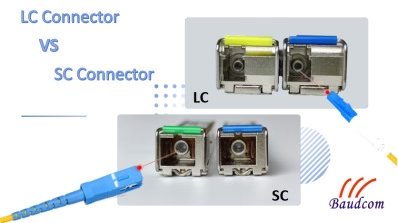

A server backplane is a high-density printed circuit board (PCB) that acts as
the electrical backbone of a server, connecting storage drives, networking, and
daughter cards without needing individual cables. It enables hot-swappable,
high-speed data transfer and power distribution, commonly used for SAS, SATA, 
and NVMe drives. 

Key aspects of server backplanes include:
- FUNCTIONALITY: They provide direct-plug connectivity for hard drivers/SSDs to
  controllers, facilitating easy hot-swapping and reducing cable management.
- TYPES: They can be PASSIVE (connector board only) or ACTIVE (including 
  switches and management components).
- APPLICATIONS: Essential in server chassis, disk arrays, and network switches
  for high-speed data flow and robust power delivery.
- TECHNOLOGY: Ofen feature 20 to 40+ layers with high-density, press-fit holes 
  to support high-speed connectors for SAS, PCIe 4.0/5.0, and NVMe drives.   



-- A motherboard is the central printed circuit board in a computer that houses
   the CPU, RAM, and essential components for processing. A backplane is a,
   usually, passive board focused on connectivity, acting as a high-speed
   highway to interconnect multiple, separate functional boards (daughter cards)
   in industrial or server systems.



-- Daughter cards in servers are modular, removable circuit boards that plug
   directly into the motherboard or a riser card to extend functionality 
   (networking, storage, I/O) without replacing the main board. Often called
   NETWORK DAUGHTER CARDS (NDCs), they provide flexible, high-speed connectivity
   options like 10 GbE or SFP slots. 

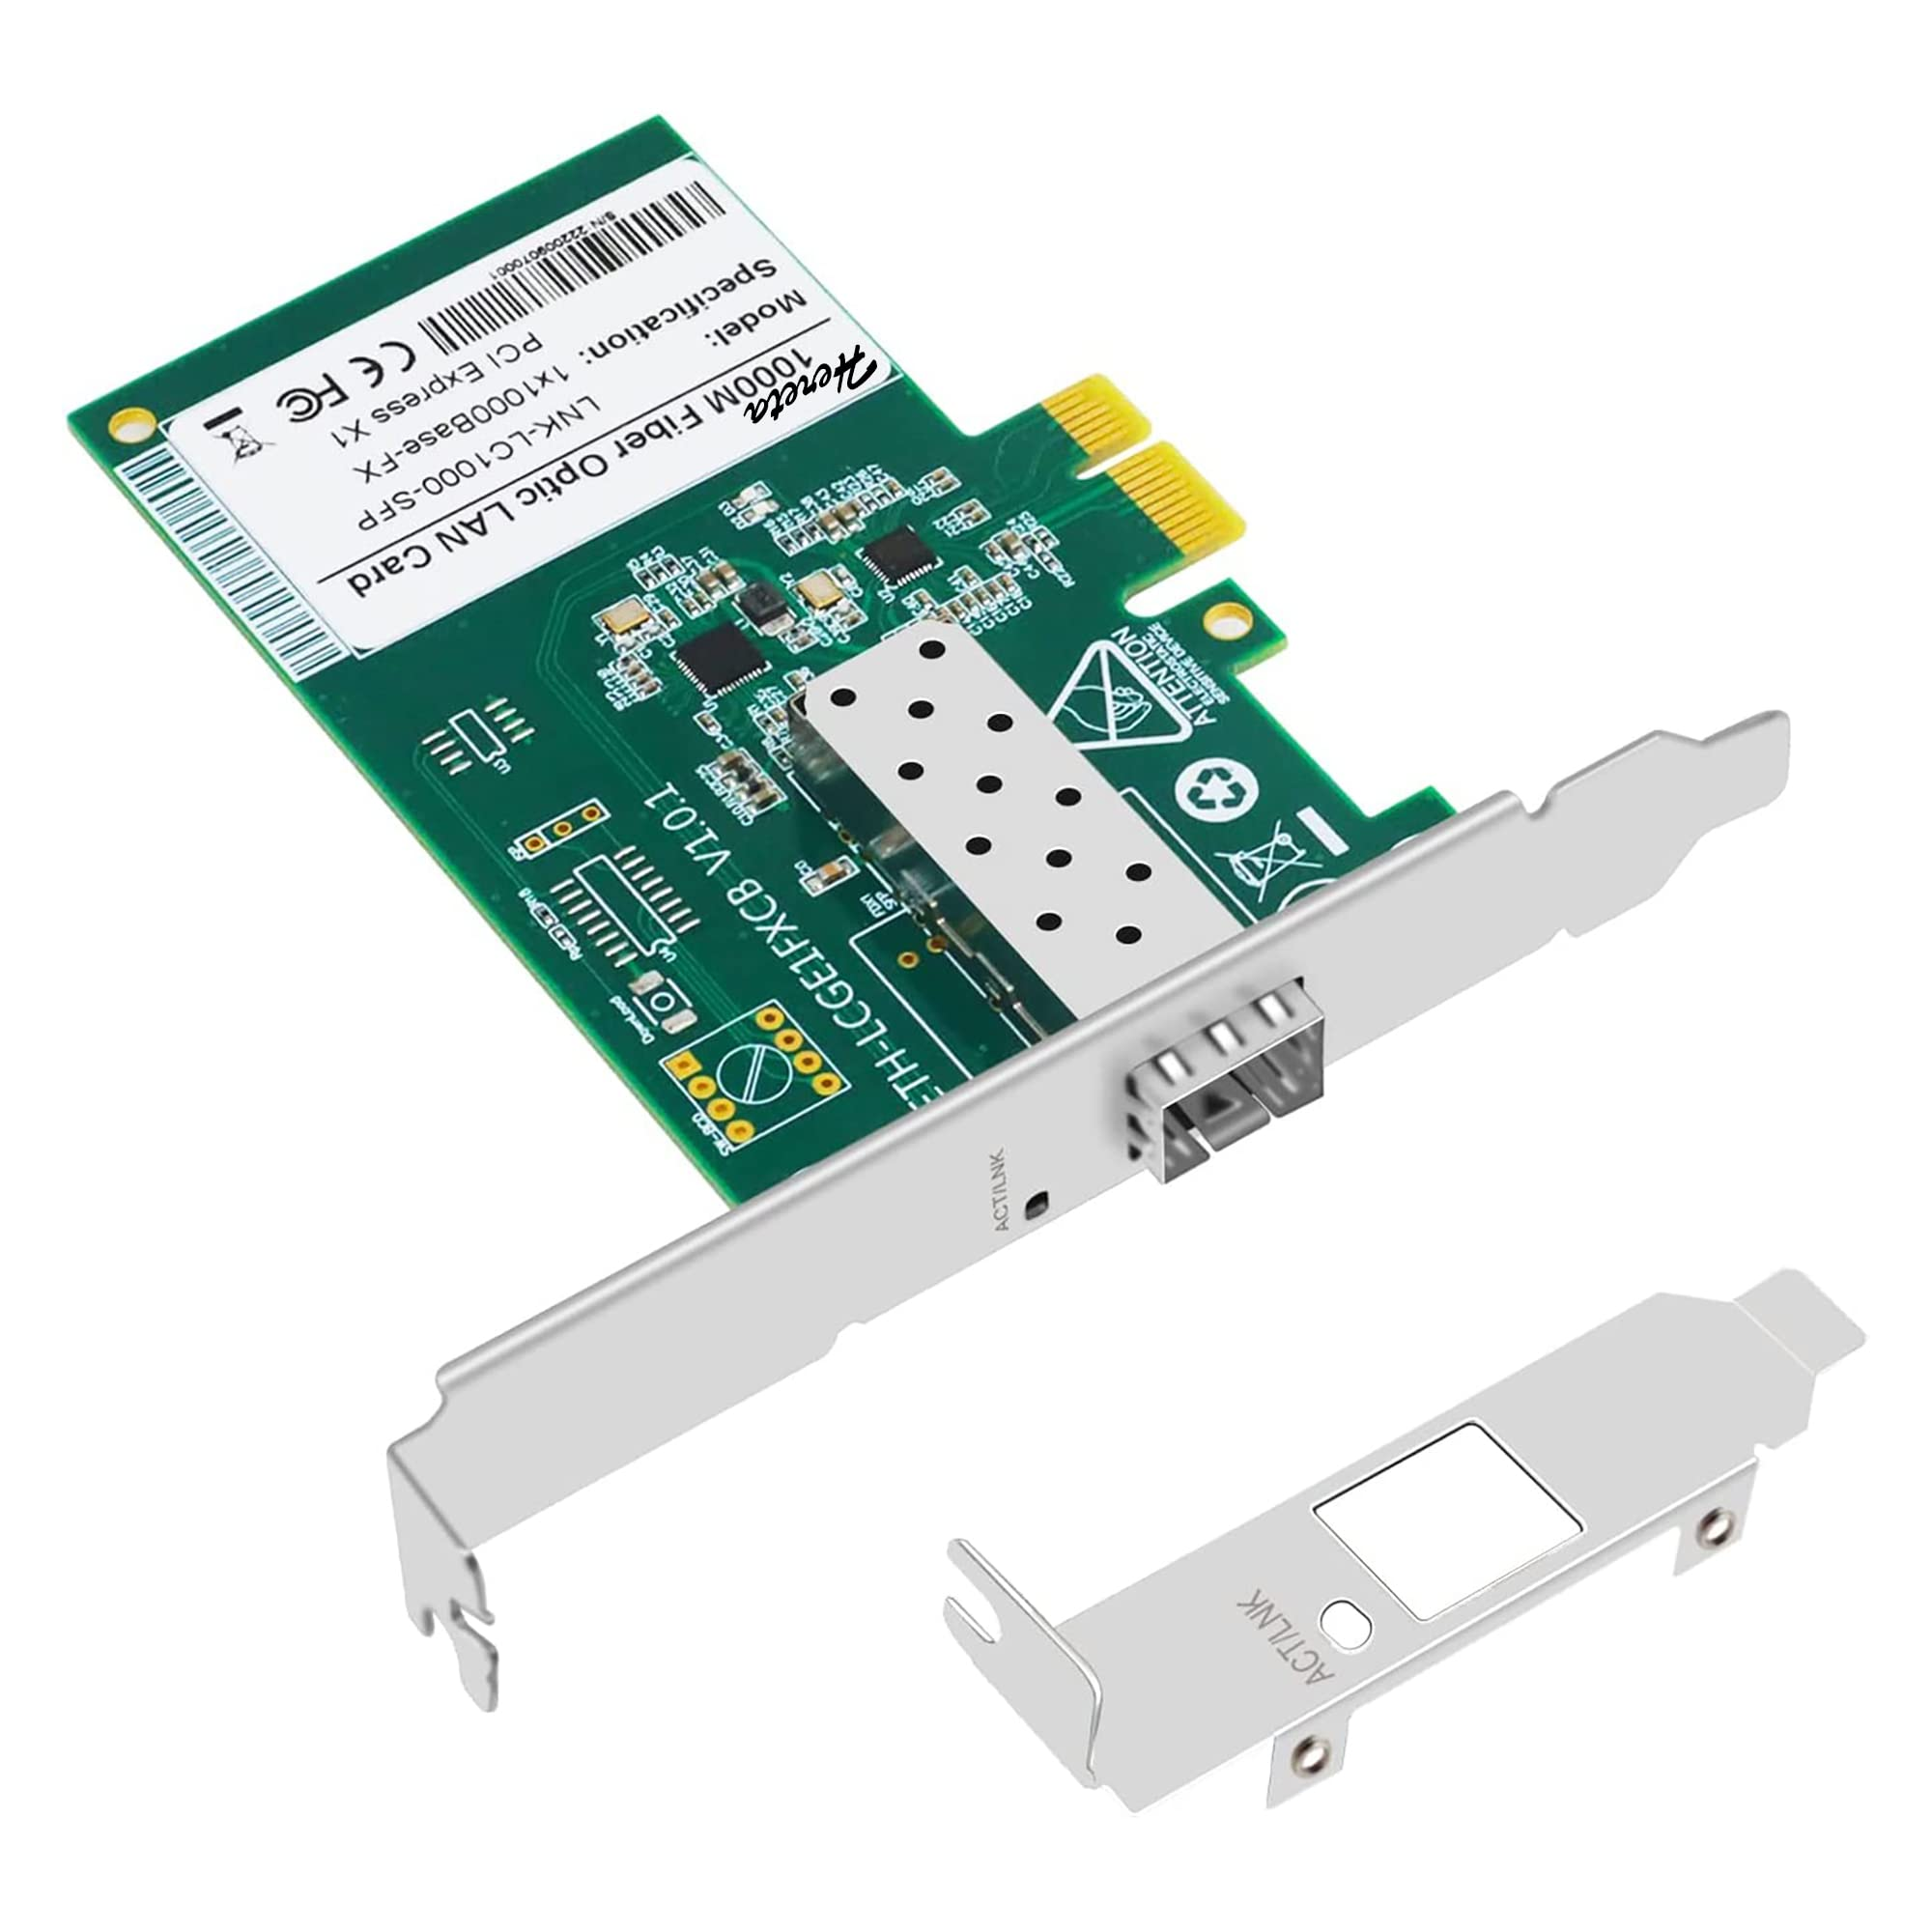

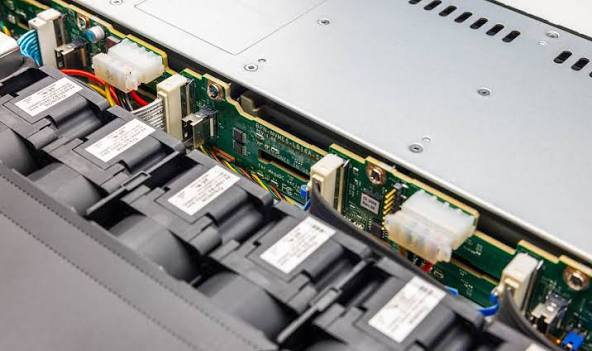


---
-- Hot-swappable hardware refers to components that can be added, removed, or
   replaced on a computer system while it remains powered on and running, 
   without causing interruptions or needing a reboot. This technology ensures
   seamless maintenance, such as changing harddrives in servers, swapping
   keyboard switches, or plugging in USB drives.



-- A ROS2 lifecycle node (or managed node) is a specialised node that follows a
   strict state machine--unconfigured, inactive, active, and finalised--to 
   manage its own lifecycle. Unlike standard nodes, these enable determinstic
   startup, safe parameter reconfiguration, and remote pausing/restarting, safe,
   ordered initialisation, runtime reconfiguration, and pausing, providing 
   better control over system startup and error recovery compared to regular
   nodes.

   KEY ASPECTS OF LIFECYCLE NODES:
   - STATES:
      * UNCONFIGURED: Initial state; node is loaded but resources are not
        initialised.
      * INACTIVE: Configured but not active; publishers/timers are disabled.
      * ACTIVE: Fully functional; node is processing data and publishing.
      * FINALISED: Terminal state before destruction.
   - TRANSITIONS: Managed via `on_configure()`, `on_activate()`, 
     `on_deactivate()`, `on_cleanup()`, and `on_shutdown()`.
   - BENEFITS: Enables robust, deterministic system startup and allows nodes to
     be restarted or reconfigured on-the-fly.
   - USE CASES: Essential for complex systems like Nav2 (e.g., `map_server`,
     `controller_server`) to ensure hardware is properly initialised.
   - MANAGEMENT: Controlled via ROS2 CLI or external managers.       



-- Tree structure in URDF (unified Robot Description Format) define a robot as 
   a hierarchical model of links (rigid bodies) and joints (connections), where
   each link has one parent and zero or more child links. This structure 
   restricts robots to open-chain, branches geometries--no closed loops are 
   allowed. 

   - ROOT LINK: The base of the tree from which all other links branch.
   - LINKS: Physical components (e.g., chassis, wheels, arms) forming the nodes
     of the tree.
   - JOINTS: Connections defining the kinematics (parent-child relationship,
     type, and limits) between links.
   - CONSTRAINT: A link cannot have more than one parent, forming a tree rather
     than a graph.
   - LOOPS: URDF does not support closed kinematic loops, these must be modeled
     as a tree by breaking the loop.      

   Key joint types defining the structure include REVOLUTE (hinge), PRISMATIC
   (sliding), and FIXED (rigidly attached).







-- A closed kinematic chain in Gazebo is a mechanism where rigid bodies form a
   closed loop (e.g., parallel robots, grippers), creating constraints that
   require special modelling beyond standard tree-structure URDFs. Gazebo 
   supports these via SDF, often using `<mimic>` joints, plugins (like gz-sim),
   or by breaking the loop into a tree and closing it with specific constraints.

   KEY ASPECTS OF CLOSED CHAINS IN GAZEBO:
   - MODELLING CONSTRAINTS: Unlike open chains (tree structures), closed chains 
     cannot be easily represented in URDF because a link cannot have two parents
     . SDF (Simulation Description Format) is required for full graph support.
   - COMMON USE CASES: They are essential for modelling parallel robots, 
     2-finger grippers, and 4-bar linkages.   
   - SIMULATION IMPLEMENTATION:
      - GAZEBO CLASSIC: Uses plugins like `libgazebo_ros2_control.so` or `mimic`
        joints to enforce constraints.
      - GAZEBO SIM (Ignition): Does not directly support closed loop in SDF;
        instead, you must model the robot as a tree and use plugins to enforce
        closure, or use gz-physics to handle them.
   - SIMULATION CHALLENGES: They can cause numerical instability (numerical
     drift) because this simulation must satisfy strict geometric constraints at
     every time step.

   COMMON WORKAROUNDS:
   - MIMIC JOINTS: Setting one joint to mimic another to simulate dependency.
   - PLUGIN-BASED CONSTRAINTS: Utilising gazebo plugins to define the 
     closed-loop constraints explicitly.
   - CONVERTING TO TREE: Structuring the URDF to represent the loop as a 
     branched tree and handling the final connection via a plugin.  



-- In robotics, IMPEDANCE refers to a control strategy that regulates the 
   relationship between the force applied by a robot's manipulator 
   (end-effector) and its resulting motion (position/velocity) when
   interacting with the environment. Rather than forcing a robot to stick to a 
   strict path, impedance control makes it behave like a programmable 
   mass-spring damper system, allowing it to yield or resist in a controlled,
   safe, and natural way.



-- Joint-space control is a ROBOTIC CONTROL METHOD that directly specifies and
   regulates the position or motion of each individual robot joint (angles for
   revolute, extension for prismatic) to achieve a desired configuration, rather
   than focusing on the Cartesian posiion of the end-effector. It is often used
   for fast, point-to-point motion, as it avoids the need for complex, 
   computationally heavy INVERSE KINEMATICS during real-time movement.    



-- F/T (Force/Torque) sensor integration is the incorporation of sensors, 
   typically at the robot's wrist, to measure 6-axis forces ($F_x, F_y, F_z$)
   and torques ($M_x, M_y, M_z$) in real time. This allows robots to "feel,"
   enabling precise, adaptive control for tasks like assembly, polishing, and
   insertion.   



-- Admittance control is a robotic control strategy that translates external
   forces (measured by a sensor) into, usually, motion, by using a virtual
   mass-spring-damper model. It enables robots to behave compliantly, making it
   ideal for safe human-robot interaction, collaborative tasks, and teaching, 
   where the robot acts, or "admits," to external inputs.    



-- Protocol Buffers (Protobuf) is a language-neutral, platform-neutral, and
   extensible mechanism developed by Google for serialising structured data,
   frequently used in robotics for high-performance, compact communication
   between components. It enables efficient, binary-formatted data exchange,
   making it faster and smaller than JSON or XML, which is ideal fopr real-time
   robotic systems.    



-- Serialisation is the process of converting complex data structures or object
   states in memory into a protable format (like bytes, JSON, or XML) that can
   be easily stored in files/databases or transmitted across networks. This
   allows the object to be reconstructed later through deserialisation, 
   preserving the original data state.

---


---    
3. WHAT DOES `write_root_*` DO?
    You are correct--it writes to the SIMULATION BUFFER.

    In high-peformance simulation, you don't move objects by talking to the "UI"
    or the Scene Tree. That is too slow. Instead:

    1. `write_root_pose_to_sim`: This teleports the obejcts to the new XYZ
       coordinates and rotations you just calculated.    
    2. `write_root_velocity_to_sim`: This sets their speed. In this script, it
       usually      

                    https://gemini.google.com/app/d4324975ae77fb67

hi. thanks. can you now on the other hand explain to me how does run_articulation.py work... and how it differs from run_rigid_object.py? thanks!

                    https://gemini.google.com/app/d4324975ae77fb67

finally! please similarly do such too for run_deformable_object.py

                    https://gemini.google.com/app/d4324975ae77fb67